## **0. Import & Load**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


## **1. EDA**
A quick visual inspection of the first few rows to confirm columns loaded correctly and to get a feel for the value ranges before running any statistics.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

**target variable: booking_complete**, 1 if booking completed, 0 otherwise Notably, `.info()` confirms zero nulls across all 50,000 rows, so no imputation is needed. `flight_day` comes in as an object (string), which we will encode before modelling.

In [4]:
print("Class balance (target = booking_complete):")
print(df['booking_complete'].value_counts(normalize=True).round(4))

Class balance (target = booking_complete):
booking_complete
0    0.8504
1    0.1496
Name: proportion, dtype: float64


**Note on Class imbalance:** Roughly **85% / 15%** split between non-bookers and bookers.

**Evaluation metric**: Accuracy alone would be misleading here. A model that predicts "no booking" for every customer would already score 85% accuracy while being commercially useless. ROC-AUC, precision, recall, and F1 for the minority class are the metrics that actually matter.

In [5]:
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Unique routes: {df['route'].nunique()}")
print(f"Unique booking origins: {df['booking_origin'].nunique()}")
print(f"Unique sales channels: {df['sales_channel'].unique()}")
print(f"Unique trip types: {df['trip_type'].unique()}")
print(f"Flight days: {df['flight_day'].unique()}")

Rows: 50,000  Columns: 14
Nulls: 0
Unique routes: 799
Unique booking origins: 104
Unique sales channels: ['Internet' 'Mobile']
Unique trip types: ['RoundTrip' 'CircleTrip' 'OneWay']
Flight days: ['Sat' 'Wed' 'Thu' 'Mon' 'Sun' 'Tue' 'Fri']


**Cardinality check to decide on encoding column data**: `Route` has **799 unique values** and `booking_origin` has **104**. These are both very high-cardinality categoricals. One-hot encoding either would explode the feature space into hundreds of sparse binary columns, diluting the signal across many near-empty features and making individual feature importances almost meaningless (each `route_XYZ` column would carry a tiny fraction of the true signal).- `sales_channel` (2 values), `trip_type` (3 values), and `flight_day` (7 values) are all low-cardinality. One-hot encoding is safe and keeps individual categories interpretable in the feature importance output later.

In [6]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


Notes from the descriptive stats: `purchase_lead` has a wide range (from very short to very long lead times). A continuous representation may not be ideal. Last-minute vs planned bookers behave differently, so bucketing this is a candidate feature engineering mov. `Length_of_stay` similarly spans a wide range - this is fine as a continuous variable for tree models. The three `wants_*` flags are binary and it is worth combining into a single "ancillary demand" score, since a customer requesting multiple add-ons is likely showing higher purchase intent than any one flag captures on its own.

## **2. Feature Engineering & Encoding:**
Now we transform the raw columns into a model-ready feature matrix. The decisions below trade off between preserving signal and keeping the feature space compact and interpretable.

In [20]:
# Frequency encoding for high-cardinality categoricals: It collapses each into one dense numeric feature ("how common is this route/country")

df['route_freq'] = df['route'].map(df['route'].value_counts())
df['booking_origin_freq'] = df['booking_origin'].map(df['booking_origin'].value_counts())
df = df.drop(columns=['route', 'booking_origin'])

KeyError: 'route'

In [8]:
# --- One-hot encoding for low-cardinality categoricals ---

day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['flight_day'] = pd.Categorical(df['flight_day'], categories=day_order, ordered=True)
df = pd.get_dummies(df, columns=['sales_channel', 'trip_type', 'flight_day'], drop_first=True)

In [9]:
# --- Engineered feature 1: ancillary demand score ---

df['ancillary_score'] = (
    df['wants_extra_baggage']
    + df['wants_preferred_seat']
    + df['wants_in_flight_meals']
)

In [10]:
# --- Engineered feature 2: Bucketing based on lead time  ---

df['lead_time_bucket'] = pd.cut(
    df['purchase_lead'],
    bins=[-1, 7, 30, 90, 1000],
    labels=['last_minute', 'short_lead', 'medium_lead', 'long_lead']
)
df = pd.get_dummies(df, columns=['lead_time_bucket'], drop_first=True)

print("Final feature set:")
print(df.dtypes)
print(f"\nTotal features (excluding target): {df.shape[1] - 1}")

Final feature set:
num_passengers                    int64
purchase_lead                     int64
length_of_stay                    int64
flight_hour                       int64
wants_extra_baggage               int64
wants_preferred_seat              int64
wants_in_flight_meals             int64
flight_duration                 float64
booking_complete                  int64
route_freq                        int64
booking_origin_freq               int64
sales_channel_Mobile               bool
trip_type_OneWay                   bool
trip_type_RoundTrip                bool
flight_day_Tue                     bool
flight_day_Wed                     bool
flight_day_Thu                     bool
flight_day_Fri                     bool
flight_day_Sat                     bool
flight_day_Sun                     bool
ancillary_score                   int64
lead_time_bucket_short_lead        bool
lead_time_bucket_medium_lead       bool
lead_time_bucket_long_lead         bool
dtype: object

Total 

All columns are now numeric or boolean and ready for modelling.

## **3. Train/Test Split**

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

X = df.drop(columns=['booking_complete'])
y = df['booking_complete']

# stratify=y preserves the 85/15 class balance in both train and test — without
# this, a random split could accidentally skew the test set and make our
# evaluation numbers noisier and less trustworthy.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate:  {y_test.mean():.4f}")

Train: (40000, 23), Test: (10000, 23)
Train positive rate: 0.1495
Test positive rate:  0.1496


## **4. Modelling using RandomForest**
 The brief explicitly recommends RandomForest, and it's a sensible choice here as it **Handles mixed feature scales and types without preprocessing**. No need to standardise numeric columns because tree splits are threshold-based not magnitude-sensitive and is **robust to noise ie. doesn't overfit as easily as a single decision tree** (the ensemble averaging over 300 trees dampens the effect of any one tree memorising training data)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',   # accounts for 85/15 class imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [13]:
# 5-fold stratified cross-validation on the training set only
# (test set is held back for final unseen evaluation)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"Cross-val ROC-AUC: {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")

Cross-val ROC-AUC: 0.7556 (+/- 0.0037)


In [14]:
# Final evaluation on held-out test set
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Test ROC-AUC: 0.7690

Classification report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.57      0.08      0.15      1496

    accuracy                           0.85     10000
   macro avg       0.72      0.54      0.53     10000
weighted avg       0.82      0.85      0.80     10000

Confusion matrix:
[[8409   95]
 [1370  126]]


**Reading the baseline results:**

**ROC-AUC (~0.77)**: Meaningfully better than random (0.50) but not exceptional. The model is picking up real signal but not enough to make highly confident individual predictions.- **Class 1 recall is very low (~8%)**. The model only catches a small fraction of actual bookers. It's playing it safe and predicting "no booking" most of the time because that's the majority class.- **Class 1 precision (~57%)**: When the model does predict a booking, it's right slightly more than half the time.- The **confusion matrix** shows the model correctly identifies ~8,400 non-bookers but misses ~1,370 of the 1,496 actual bookers.The honest business takeaway is that the **current features** carry moderate but not strong signal for booking intent. We now **benchmark other model families** to see whether the ceiling is set by the data itself or by the model choice. Benchmarking against Logistic Regression, Gradient Boosting, XGBoost, comparing RF against different model families tells us whether ~0.77 AUC is a data ceiling  or a model-choice ceiling.

## **5. Model Comparison**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# LogReg needs scaled features (magnitude-sensitive coefficients + regularisation);
# tree-based models don't (splits are order-invariant, magnitude-independent).
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# XGBoost import — install if not present
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    print("XGBoost not installed — skipping. Install with: pip install xgboost")
    xgb_available = False

In [16]:
models = {
    'Logistic Regression': (
        LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
        True   # needs scaling
    ),
    'Random Forest': (rf, False),   # already fitted
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        False
    ),
}

if xgb_available:
    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    models['XGBoost'] = (
        XGBClassifier(
            scale_pos_weight=pos_weight,
            eval_metric='logloss',
            random_state=42,
            use_label_encoder=False
        ),
        False
    )

results = []

for name, (model, needs_scaling) in models.items():
    Xtr = X_train_scaled if needs_scaling else X_train
    Xte = X_test_scaled if needs_scaling else X_test

    if name != 'Random Forest':   # RF already fit
        model.fit(Xtr, y_train)

    # Train AUC — how well the model fits the data it saw
    train_proba = model.predict_proba(Xtr)[:, 1]
    train_auc = roc_auc_score(y_train, train_proba)

    # Cross-val AUC — how well it generalises to unseen folds
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    # Test AUC — the final unseen-data check
    test_proba = model.predict_proba(Xte)[:, 1]
    test_auc = roc_auc_score(y_test, test_proba)

    results.append({
        'Model': name,
        'Train AUC': round(train_auc, 4),
        'CV AUC (mean)': round(cv_scores.mean(), 4),
        'CV AUC (std)': round(cv_scores.std(), 4),
        'Test AUC': round(test_auc, 4),
        'Overfit Gap (Train - Test)': round(train_auc - test_auc, 4)
    })

results_df = pd.DataFrame(results).sort_values('Test AUC', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model  Train AUC  CV AUC (mean)  CV AUC (std)  Test AUC  Overfit Gap (Train - Test)
            XGBoost     0.9179         0.7674        0.0051    0.7787                      0.1393
  Gradient Boosting     0.7751         0.7613        0.0040    0.7733                      0.0018
      Random Forest     1.0000         0.7556        0.0037    0.7690                      0.2310
Logistic Regression     0.6818         0.6803        0.0067    0.6807                      0.0010


All four models converge in the ~0.68–0.78 test AUC range. That ~0.10 spread between the worst (LogReg) and best (XGBoost) is meaningful but modest. This ** means** that the data has a soft ceiling around 0.77–0.78 AUC that no model choice can break through.
**XGBoost is the highest-performing model** on unseen (CV) data but **gradient boost** has near-zero overfit gap, so its 0.7733 test AUC is a very stable and reliable.

## **6. Feature importance & Pruning**

All feature importances:
booking_origin_freq             0.154056
purchase_lead                   0.146471
route_freq                      0.140257
length_of_stay                  0.120710
flight_hour                     0.119052
flight_duration                 0.079619
num_passengers                  0.042291
ancillary_score                 0.024206
flight_day_Tue                  0.015513
flight_day_Thu                  0.015065
flight_day_Wed                  0.014891
flight_day_Fri                  0.014550
flight_day_Sun                  0.013958
flight_day_Sat                  0.013861
wants_in_flight_meals           0.013093
lead_time_bucket_medium_lead    0.012639
sales_channel_Mobile            0.012427
lead_time_bucket_short_lead     0.012054
wants_extra_baggage             0.011841
wants_preferred_seat            0.011069
lead_time_bucket_long_lead      0.009505
trip_type_RoundTrip             0.001800
trip_type_OneWay                0.001074
dtype: float64


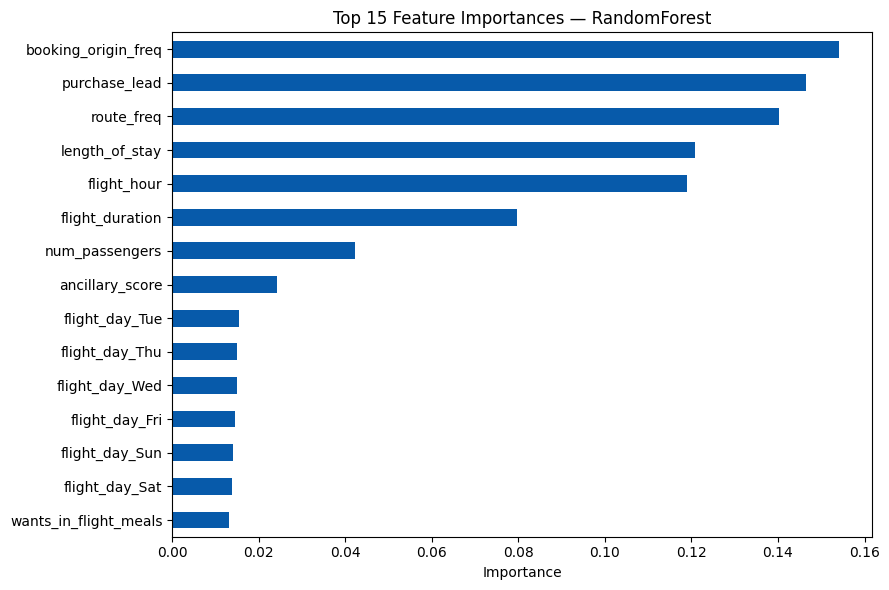

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("All feature importances:")
print(importances)

plt.figure(figsize=(9, 6))
importances.head(15).sort_values().plot(kind='barh', color='#075AAA')
plt.title('Top 15 Feature Importances - RF')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpreting the top features:**
The top drivers cluster around a few themes: **Where the customer is** (`booking_origin_freq`, `route_freq`). Geography matters, both in terms of common markets and common routes. **When and how long** (`purchase_lead`, `length_of_stay`, `flight_hour`, `flight_duration`) , timing and trip length shape booking intent, **Trip size** (`num_passengers`), solo vs group bookings behave differently, **Engineered `ancillary_score`** makes the top 10, validating the decision to combine the three "wants" flags. The individual `flight_day_*` and lead-time bucket dummies contribute very little each. Most day/bucket signal isn't strong enough to move outcomes materially.

### **Pruning:**
The bottom ~half of features contribute almost nothing individually. Refitting on just the top features tests whether a leaner model matches full-feature performance. A leaner model is more interpretable, faster to serve, and less prone to noise-fitting.

In [19]:
# Refit using only the top 8 features
top_features = importances.head(8).index.tolist()
print(f"Training on top {len(top_features)} features: {top_features}")

X_train_pruned = X_train[top_features]
X_test_pruned = X_test[top_features]

rf_pruned = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_pruned.fit(X_train_pruned, y_train)

cv_auc_pruned = cross_val_score(rf_pruned, X_train_pruned, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
test_auc_pruned = roc_auc_score(y_test, rf_pruned.predict_proba(X_test_pruned)[:, 1])

print(f"\nFull-feature model:  CV AUC = {cv_auc.mean():.4f} | Test AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.4f}")
print(f"Pruned (top 8):      CV AUC = {cv_auc_pruned.mean():.4f} | Test AUC = {test_auc_pruned:.4f}")

Training on top 8 features: ['booking_origin_freq', 'purchase_lead', 'route_freq', 'length_of_stay', 'flight_hour', 'flight_duration', 'num_passengers', 'ancillary_score']

Full-feature model:  CV AUC = 0.7556 | Test AUC = 0.7690
Pruned (top 8):      CV AUC = 0.7622 | Test AUC = 0.7741


The **pruned model is slightly better** than the full-feature model on both CV and test AUC (+0.007 CV, +0.005 test). Consider using the pruned model for final analysis.